- ## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

plt.style.use("default")
plt.rcParams["figure.figsize"] = (12,5)
plt.rcParams["font.size"] = 12

- ## GitHub URLs

In [2]:
RAW_GAP10 = (
    "https://raw.githubusercontent.com/"
    "Adrita-Khan/lightcurve-imputation/main/"
    "data/corrupted_data/gap_10.csv"
)

RAW_GAP30 = (
    "https://raw.githubusercontent.com/"
    "Adrita-Khan/lightcurve-imputation/main/"
    "data/corrupted_data/gap_30.csv"
)

RAW_GAP50 = (
    "https://raw.githubusercontent.com/"
    "Adrita-Khan/lightcurve-imputation/main/"
    "data/corrupted_data/gap_50.csv"
)

- ## Load the Data

In [3]:
gap10 = pd.read_csv(RAW_GAP10)
gap30 = pd.read_csv(RAW_GAP30)
gap50 = pd.read_csv(RAW_GAP50)

datasets = {
    "10": gap10,
    "30": gap30,
    "50": gap50
}

- ## Mean Imputation Function

In [4]:
def mean_fill(df):
    """
    Replace missing values with the mean of the
    observed flux.
    """

    result = df.copy()

    mean_value = result["corrupted_flux"].mean()

    result["imputed_flux"] = result["corrupted_flux"].fillna(
        mean_value
    )

    return result, mean_value

- ## Apply Mean Imputation

In [5]:
results = {}

for level, df in datasets.items():

    reconstructed, mean_value = mean_fill(df)

    results[level] = reconstructed

    print(f"{level}% Missing")

    print(f"Mean Flux = {mean_value:.6f}")

    print()

10% Missing
Mean Flux = 0.997752

30% Missing
Mean Flux = 0.996044

50% Missing
Mean Flux = 0.996773



- ## Compare Before and After

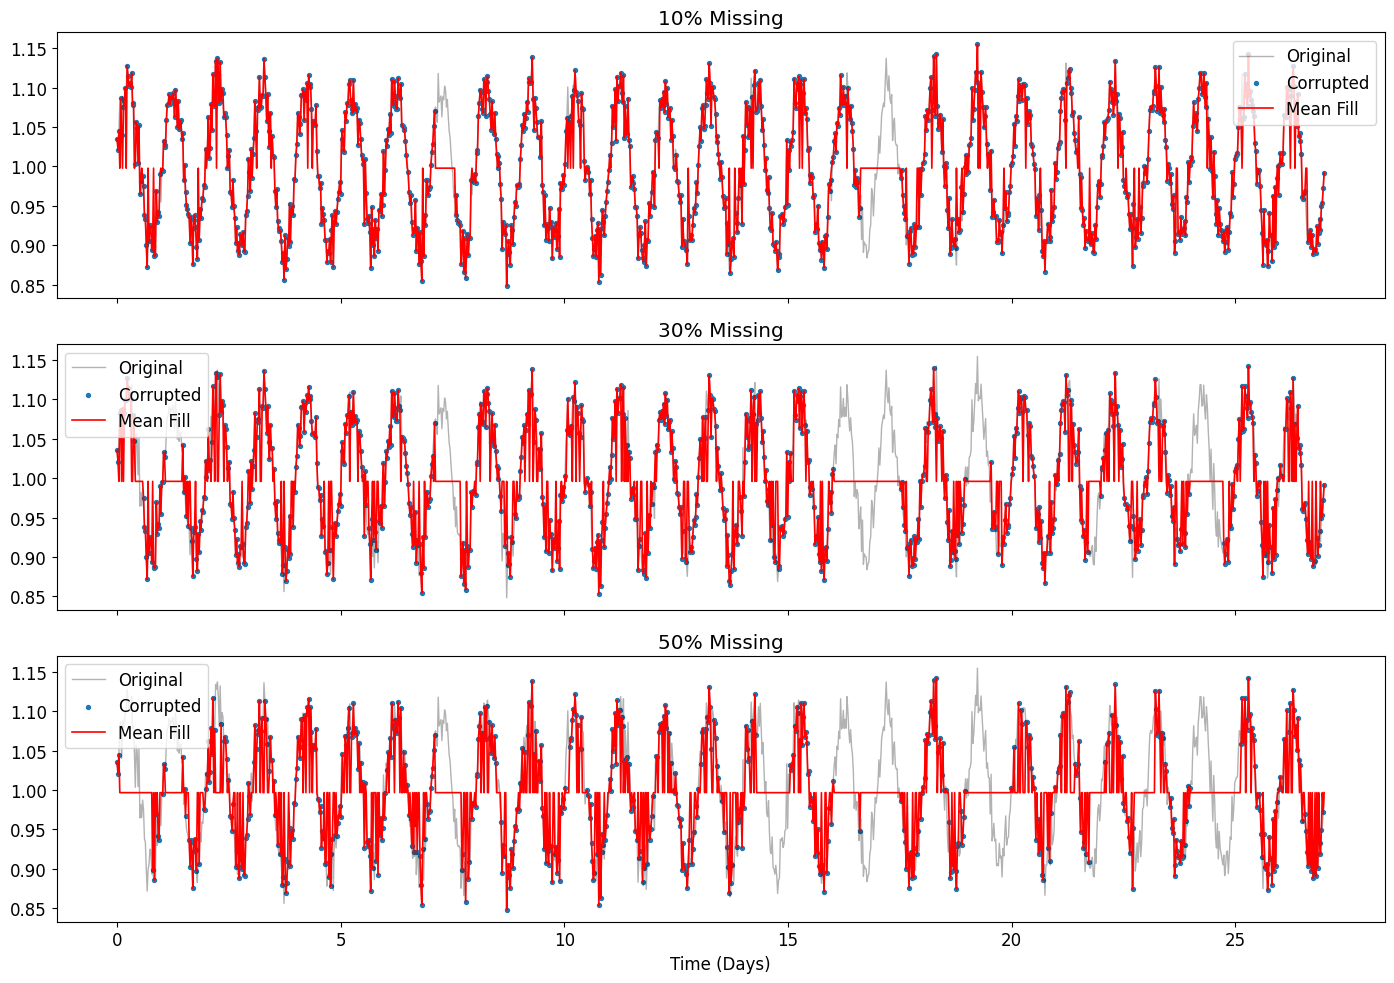

In [6]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14,10),
    sharex=True
)

for ax, (level, df) in zip(axes, results.items()):

    ax.plot(
        df["time"],
        df["observed_flux"],
        color="black",
        alpha=0.3,
        linewidth=1,
        label="Original"
    )

    ax.scatter(
        df["time"],
        df["corrupted_flux"],
        s=8,
        label="Corrupted"
    )

    ax.plot(
        df["time"],
        df["imputed_flux"],
        color="red",
        linewidth=1.2,
        label="Mean Fill"
    )

    ax.set_title(f"{level}% Missing")

    ax.legend()

plt.xlabel("Time (Days)")

plt.tight_layout()

plt.show()

- ## Plot Only the Imputed Points

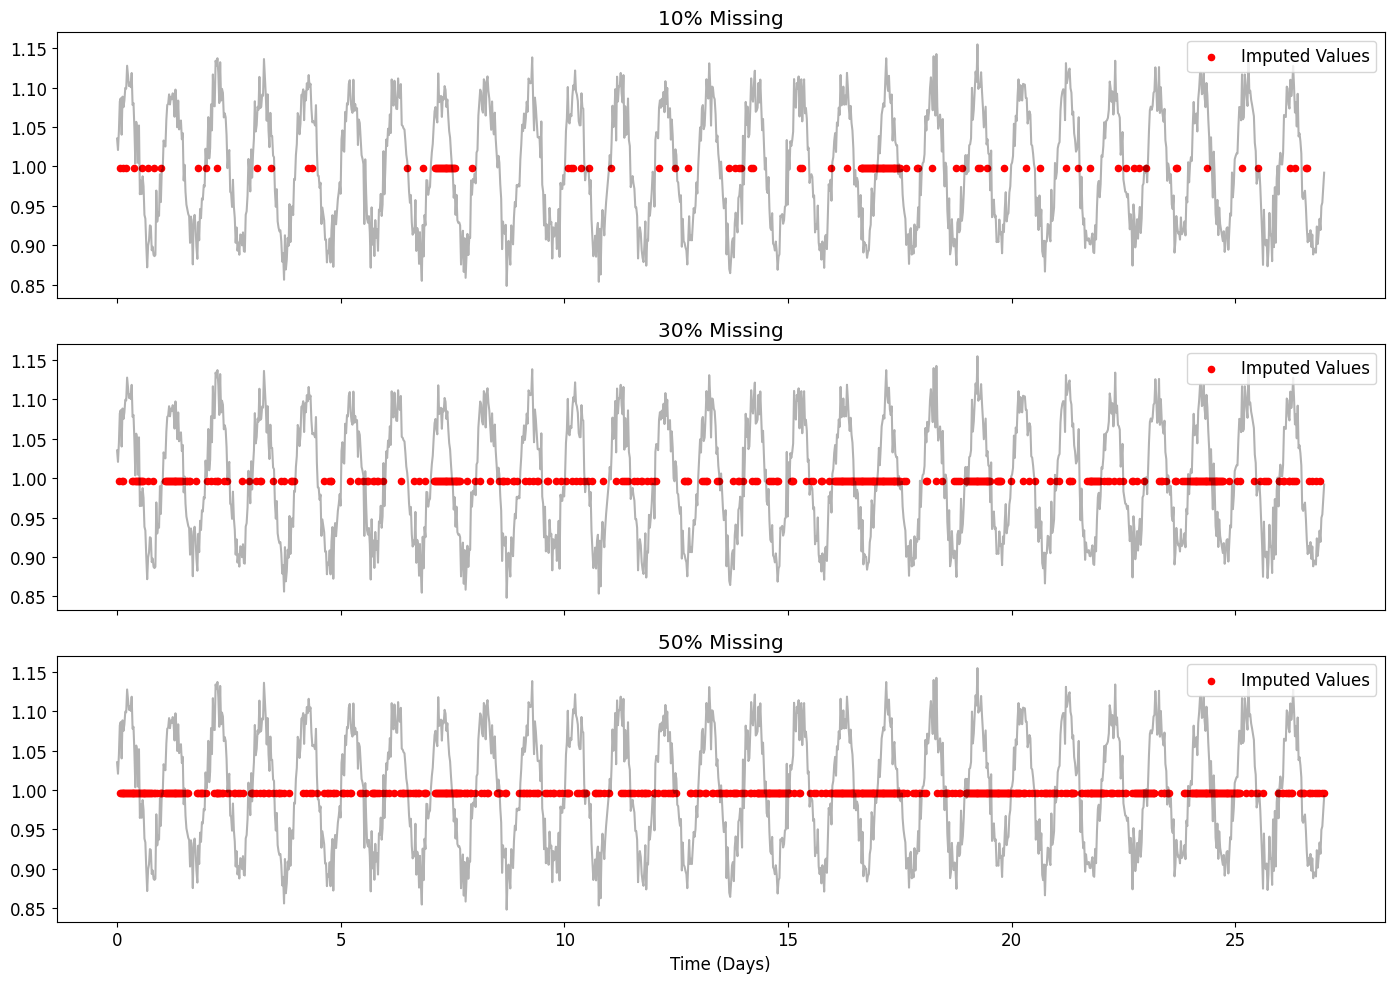

In [7]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14,10),
    sharex=True
)

for ax, (level, df) in zip(axes, results.items()):

    missing = df["mask"] == 0

    ax.plot(
        df["time"],
        df["observed_flux"],
        color="black",
        alpha=0.3
    )

    ax.scatter(
        df.loc[missing, "time"],
        df.loc[missing, "imputed_flux"],
        color="red",
        s=20,
        label="Imputed Values"
    )

    ax.set_title(f"{level}% Missing")

    ax.legend()

plt.xlabel("Time (Days)")

plt.tight_layout()

plt.show()

- ## Summary

In [8]:
summary = []

for level, df in results.items():

    summary.append({

        "Missing (%)": level,

        "Mean Used": df["imputed_flux"].mean(),

        "Remaining NaN": df["imputed_flux"].isna().sum()

    })

summary = pd.DataFrame(summary)

summary

,Missing (%),Mean Used,Remaining NaN
0,10,0.997752,0
1,30,0.996044,0
2,50,0.996773,0


- ## Save the Results

In [9]:
OUTPUT_DIR = Path("data/imputed_data/mean_fill")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

for level, df in results.items():

    filename = OUTPUT_DIR / f"mean_fill_{level}.csv"

    df.to_csv(
        filename,
        index=False
    )

    print(f"Saved: {filename}")

Saved: data/imputed_data/mean_fill/mean_fill_10.csv
Saved: data/imputed_data/mean_fill/mean_fill_30.csv
Saved: data/imputed_data/mean_fill/mean_fill_50.csv


- ## Quick Verification

In [10]:
for level, df in results.items():

    print("=" * 60)

    print(f"{level}% Missing")

    print(df.head())

10% Missing
     time  ideal_flux  observed_flux  corrupted_flux  mask  imputed_flux
0  0.0000    1.000000       1.035281        1.035281     1      1.035281
1  0.0204    1.012783       1.020786        1.020786     1      1.020786
2  0.0408    1.025356       1.044930        1.044930     1      1.044930
3  0.0612    1.037512       1.082330             NaN     0      0.997752
4  0.0816    1.049054       1.086405        1.086405     1      1.086405
30% Missing
     time  ideal_flux  observed_flux  corrupted_flux  mask  imputed_flux
0  0.0000    1.000000       1.035281        1.035281     1      1.035281
1  0.0204    1.012783       1.020786        1.020786     1      1.020786
2  0.0408    1.025356       1.044930             NaN     0      0.996044
3  0.0612    1.037512       1.082330        1.082330     1      1.082330
4  0.0816    1.049054       1.086405        1.086405     1      1.086405
50% Missing
     time  ideal_flux  observed_flux  corrupted_flux  mask  imputed_flux
0  0.0000    1.